## Settings

In [281]:
## auto reload modules
%reload_ext autoreload
%autoreload 2

## Dependencies

In [282]:
## libraries
import sys
from pathlib import Path

## path
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

## modules
from src.data.builders import load_processed_data
from src.estimators.factories import load_estimators
from src.evaluators.resampling import (
    logo_cross_valid,
    kfold_cross_valid
)
from src.evaluators.transfering import (
    compile_domain_transfer,
    results_domain_transfer,
)

## constants
from src.evaluators.config import (
    FEAT_X,
    FEAT_Z, 
    TARGET
)

## Initialization

In [283]:
## reproducibility
N_DECIMALS = 2
N_REPEATS = 30
RANDOM_STATE = 42

## load data and models
data = load_processed_data()
models = load_estimators(random_state = RANDOM_STATE)

## view data shape
n_obs, n_feat = data.shape
print(f"Original Data: {n_feat} features, {n_obs} observations")

## view model surface
n_mods = len(models)
print(f"Learned Models: {n_mods} estimators")

Original Data: 32 features, 25 observations
Learned Models: 9 estimators


## Training

In [284]:
## leave-one-group-out cross validation (domain)
if "results_dict_domain" not in globals():
    results_dict_domain = dict()
    for name, model in models.items():
        print(f"Training {name}...")
        frontier, _ = logo_cross_valid(
            data = data,
            feat_x = FEAT_X,
            feat_z = FEAT_Z,
            estimator_c = model.estimator_c,
            estimator_r = model.estimator_r,
            target = TARGET,
            group = "domain",  ## fold on domain
            n_repeats = N_REPEATS,
            random_state = RANDOM_STATE
        )
        frontier["model"] = name
        results_dict_domain[name] = frontier


In [285]:
## leave-one-group-out cross validation (discipline)
if "results_dict_disc" not in globals():
    results_dict_disc = dict()
    for name, model in models.items():
        print(f"Training {name}...")
        frontier, _ = logo_cross_valid(
            data = data,
            feat_x = FEAT_X,
            feat_z = FEAT_Z,
            estimator_c = model.estimator_c,
            estimator_r = model.estimator_r,
            target = TARGET,
            group = "discipline",  ## fold on discipline
            n_repeats = N_REPEATS,
            random_state = RANDOM_STATE
        )
        frontier["model"] = name
        results_dict_disc[name] = frontier


In [286]:
## 5-fold cross validation
if "results_dict_5fold" not in globals():
    results_dict_5fold = dict()
    for name, model in models.items():
        print(f"Training {name}...")
        frontier, _ = kfold_cross_valid(
            data = data,
            feat_x = FEAT_X,
            feat_z = FEAT_Z,
            estimator_c = model.estimator_c,
            estimator_r = model.estimator_r,
            target = TARGET,
            n_splits = 5,  ## fold on random 80-20 split
            n_repeats = N_REPEATS,
            random_state = RANDOM_STATE
        )
        frontier["model"] = name
        results_dict_5fold[name] = frontier


In [287]:
## 10-fold cross validation
if "results_dict_10fold" not in globals():
    results_dict_10fold = dict()
    for name, model in models.items():
        print(f"Training {name}...")
        frontier, _ = kfold_cross_valid(
            data = data,
            feat_x = FEAT_X,
            feat_z = FEAT_Z,
            estimator_c = model.estimator_c,
            estimator_r = model.estimator_r,
            target = TARGET,
            n_splits = 10,  ## fold on random 90-10 split
            n_repeats = N_REPEATS,
            random_state = RANDOM_STATE
        )
        frontier["model"] = name
        results_dict_10fold[name] = frontier


## Post-Processing

In [288]:
## compile domain-transfer results
results_data_domain = compile_domain_transfer(results = results_dict_domain)
results_data_disc = compile_domain_transfer(results = results_dict_disc)
results_data_5fold = compile_domain_transfer(results = results_dict_5fold)
results_data_10fold = compile_domain_transfer(results = results_dict_10fold)

## Domain Transfer Test
Four resampling regimes evaluate held-out-group transferability against random-split baselines. Leave-one-group-out (LOGO) cross-validation by domain and discipline assesses generalization to unseen groups; random 5-fold and 10-fold cross-validation establish reference baselines.

- **Domain (LOGO)**: Held-out across 5 domains; group splits fixed, learner initializations vary across repeats.
- **Discipline (LOGO)**: Held-out across 25 disciplines; group splits fixed, learner initializations vary across repeats.
- **Random (5-Fold)**: Repeated shuffled 80–20 splits.
- **Random (10-Fold)**: Repeated shuffled 90–10 splits.

### Reporting Convention
Each regime contributes one value per estimator, averaged across groups or folds and repeats. The summary table reports the median across estimators. `EI` is shown as median `[Q1–Q3]`; `VR`, `MV`, and `MS` report medians, with `MV` and `MS` on the log-target scale. Aggregations are equally weighted across groups, folds, repeats, and estimators.

In [289]:
## compile transfer bounds and baseline benchmarks
results = results_domain_transfer(
    {"Domain (LOGO)": results_data_domain, "Discipline (LOGO)": results_data_disc},
    {"Random (5-Fold)": results_data_5fold, "Random (10-Fold)": results_data_10fold},
    keys = ("Transfer", "Standard"),
    indicies = ("Evaluation", "Method"),
    n_repeats = N_REPEATS,
    random_state = RANDOM_STATE,
    decimals = N_DECIMALS
)

display(results)

Cross-Validation: 9 models, 30 repeats (seeds 42-71)
Across-model aggregation: median of model-level means
Resampling: LOGO splits are fixed across repeats; random k-fold splits are reshuffled across repeats
Weighting: groups, folds, repeats, and models are equally weighted; results are not observation-weighted


_Transfer `EI` is 0.79 (Domain LOGO) and 0.76 (Discipline LOGO), comparable to the random-split baselines (0.79–0.80). Violation rates differ across regimes (0.044–0.080) but remain low throughout, suggesting that estimator performance under strict held-out-group evaluation does not depart materially from random-partition baselines._

## Visualization

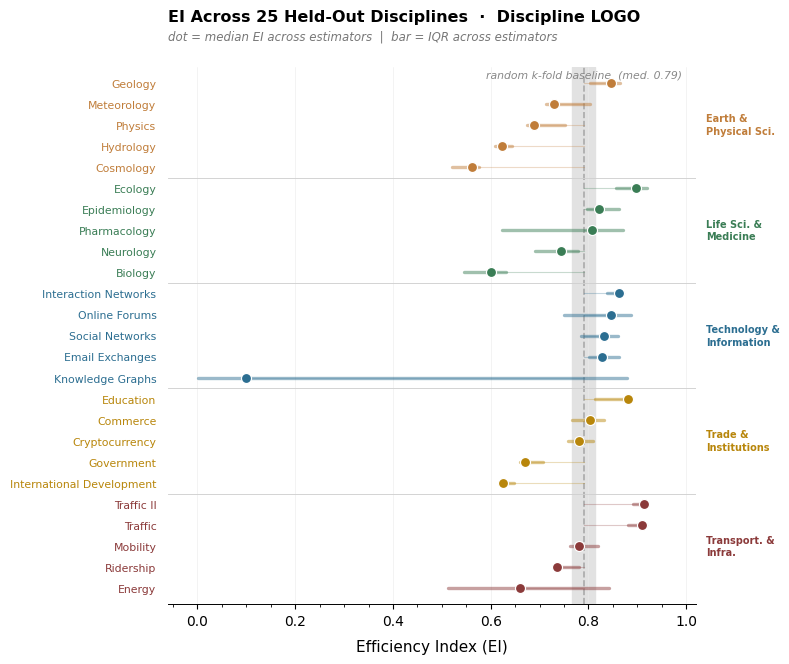

In [290]:

## libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.transforms import blended_transform_factory

## ── palette (one color per domain) ──────────────────────────────────────────
DOMAIN_PALETTE = {
    "Earth & Physical Sciences":      "#C07D3A",
    "Life Sciences & Medicine":       "#3A7D55",
    "Technology & Information":       "#2C6E91",
    "Trade & Institutions":           "#B8860B",
    "Transportation & Infrastructure":"#8B3A3A",
}
FALLBACK_CLR = "#555555"

## ── discipline → domain mapping ──────────────────────────────────────────────
disc_domain_map = (
    data[["discipline", "domain"]]
    .drop_duplicates()
    .set_index("discipline")["domain"]
    .to_dict()
)

## ── aggregate discipline LOGO: median EI ± IQR across estimators per fold ────
disc_agg = (
    results_data_disc
    .dropna(subset=["ei"])
    .groupby("group")["ei"]
    .agg(
        median = "median",
        q1     = lambda x: x.quantile(0.25),
        q3     = lambda x: x.quantile(0.75),
    )
    .reset_index()
    .rename(columns={"group": "discipline"})
)
disc_agg["domain"] = disc_agg["discipline"].map(disc_domain_map).fillna("Unknown")

## ── k-fold pooled baseline ────────────────────────────────────────────────────
_baseline = pd.concat([
    results_data_5fold["ei"].dropna(),
    results_data_10fold["ei"].dropna(),
])
baseline_med = _baseline.median()
baseline_q1  = _baseline.quantile(0.25)
baseline_q3  = _baseline.quantile(0.75)

## ── sort: domain order → median EI descending within domain ──────────────────
_domain_order = [d for d in DOMAIN_PALETTE if d in disc_agg["domain"].unique()]
disc_agg["_drank"] = disc_agg["domain"].map(
    {d: i for i, d in enumerate(_domain_order)}
).fillna(999)
disc_agg = disc_agg.sort_values(
    ["_drank", "median"], ascending=[True, False]
).reset_index(drop=True)

n_disc = len(disc_agg)

## ── figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8.8, 6.8))
fig.subplots_adjust(top=0.88, right=0.78, left=0.18, bottom=0.09)

## title + subtitle via fig.text so they never collide
fig.text(0.18, 0.965,
         "EI Across 25 Held-Out Disciplines  ·  Discipline LOGO",
         ha="left", va="top", fontsize=11.5, fontweight="semibold",
         transform=fig.transFigure)
fig.text(0.18, 0.935,
         "dot = median EI across estimators  |  bar = IQR across estimators",
         ha="left", va="top", fontsize=8.5, color="#777",
         fontstyle="italic", transform=fig.transFigure)

## baseline band + dashed median line
ax.axvspan(baseline_q1, baseline_q3,
           color="#E2E2E2", zorder=0)
ax.axvline(baseline_med,
           color="#AAAAAA", lw=1.2, ls="--", zorder=1)

## baseline label inside the plot, top of band
_trans_xd = blended_transform_factory(ax.transData, ax.transAxes)
ax.text(
    baseline_med, 0.995,
    f"random k-fold baseline  (med. {baseline_med:.2f})",
    transform=_trans_xd,
    ha="center", va="top",
    fontsize=7.8, color="#888", fontstyle="italic",
    clip_on=False,
)

## lollipop rows
for i, row in disc_agg.iterrows():
    y     = n_disc - 1 - i
    color = DOMAIN_PALETTE.get(row["domain"], FALLBACK_CLR)

    ax.plot(
        [baseline_med, row["median"]], [y, y],
        color=color, lw=0.8, alpha=0.28, zorder=2,
    )
    ax.plot(
        [row["q1"], row["q3"]], [y, y],
        color=color, lw=2.4, alpha=0.48, solid_capstyle="round", zorder=3,
    )
    ax.scatter(
        row["median"], y,
        color=color, s=52, zorder=5, edgecolors="white", linewidths=0.85,
    )

## domain group separators
_prev = None
for i, row in disc_agg.iterrows():
    if _prev is not None and row["domain"] != _prev:
        ax.axhline(n_disc - i + 0.5 - 1,
                   color="#D0D0D0", lw=0.65, zorder=1)
    _prev = row["domain"]

## y-axis: discipline labels colored by domain
ax.set_yticks(range(n_disc))
ax.set_yticklabels(disc_agg["discipline"].iloc[::-1], fontsize=7.8)
for lbl, (_, row) in zip(ax.get_yticklabels(), disc_agg.iloc[::-1].iterrows()):
    lbl.set_color(DOMAIN_PALETTE.get(row["domain"], FALLBACK_CLR))

## domain labels on the right
_trans_r = blended_transform_factory(ax.transAxes, ax.transData)
_short   = {
    "Earth & Physical Sciences":       "Earth &\nPhysical Sci.",
    "Life Sciences & Medicine":        "Life Sci. &\nMedicine",
    "Technology & Information":        "Technology &\nInformation",
    "Trade & Institutions":            "Trade &\nInstitutions",
    "Transportation & Infrastructure": "Transport. &\nInfra.",
}
for domain in _domain_order:
    rows = disc_agg[disc_agg["domain"] == domain]
    if rows.empty:
        continue
    y_pos = [n_disc - 1 - i for i in rows.index]
    y_mid = (min(y_pos) + max(y_pos)) / 2
    ax.text(
        1.018, y_mid, _short.get(domain, domain),
        transform=_trans_r, ha="left", va="center",
        fontsize=7.0, color=DOMAIN_PALETTE[domain], fontweight="semibold",
        linespacing=1.35, clip_on=False,
    )

## axes dressing
ax.set_xlabel("Efficiency Index (EI)", fontsize=11, labelpad=8)
_x_lo = min(disc_agg["q1"].min(), baseline_q1) - 0.06
_x_hi = max(disc_agg["q3"].max(), baseline_q3) + 0.10
ax.set_xlim(_x_lo, _x_hi)
ax.set_ylim(-0.75, n_disc - 0.25)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_linewidth(0.7)
ax.xaxis.grid(True, lw=0.4, color="#EBEBEB", zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="y", left=False, pad=5)
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.05))


plt.show()


Saved figure to: /Users/nickkunz/Documents/Nick’s MacBook Pro/Python/graph-capacity/outputs/figures/transfer_invariance.png


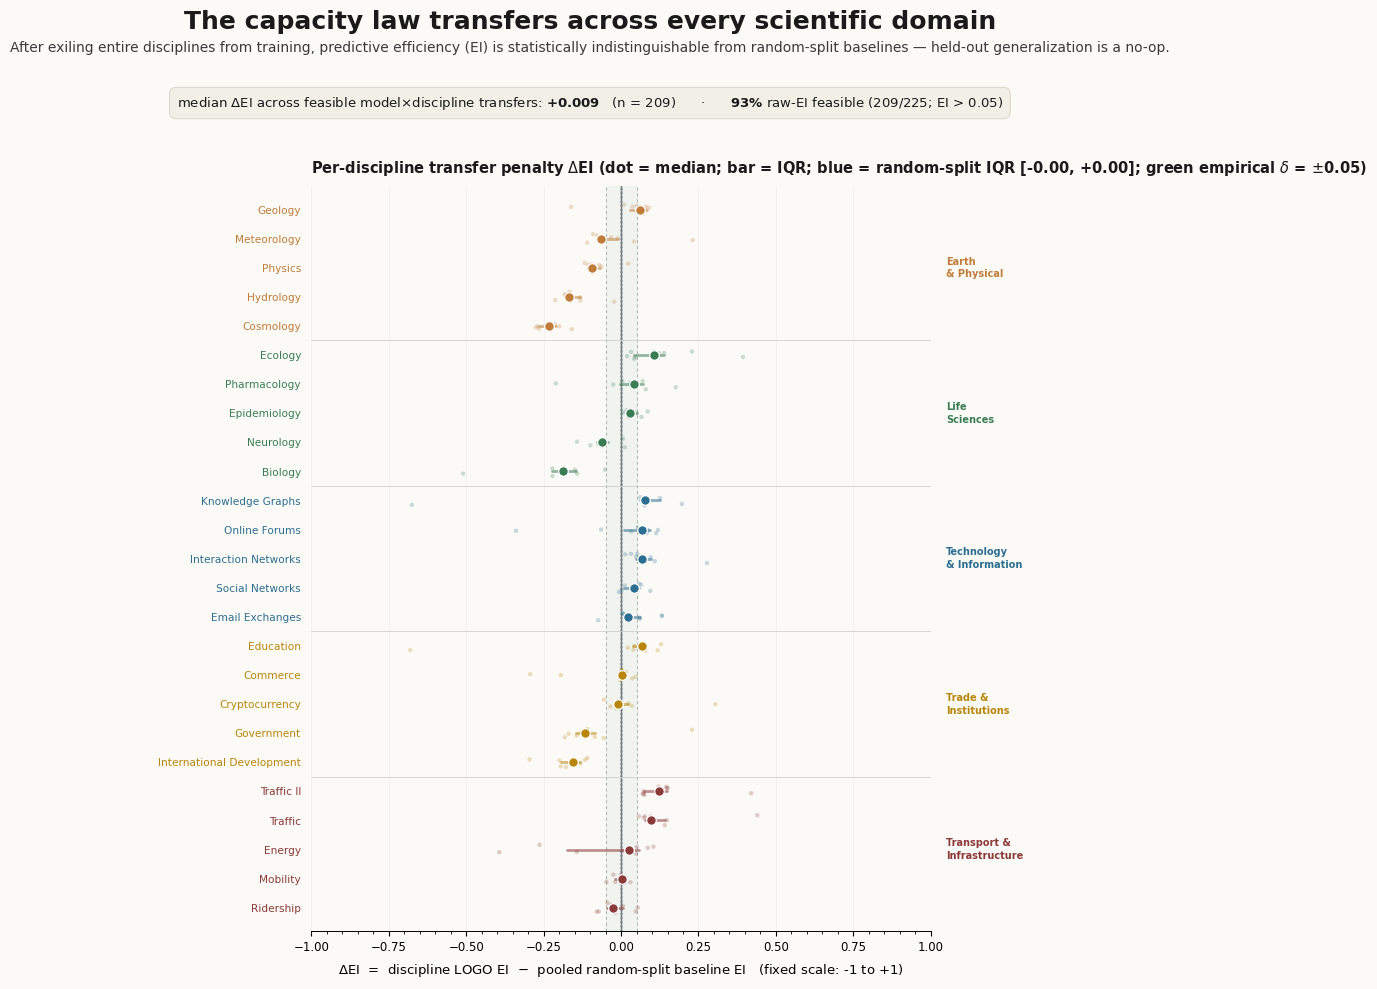

In [298]:
## libraries
from src.visualizers.visualizing import plot_transfer_invariance

## discipline -> domain map
disc_domain_map = (
    data[["discipline", "domain"]]
    .drop_duplicates()
    .set_index("discipline")["domain"]
    .to_dict()
)

## render money-shot transfer-invariance figure
fig, axes = plot_transfer_invariance(
    results_data_domain  = results_data_domain,
    results_data_disc    = results_data_disc,
    results_data_5fold   = results_data_5fold,
    results_data_10fold  = results_data_10fold,
    disc_domain_map      = disc_domain_map,
    random_state         = RANDOM_STATE,
    show                 = False,
)

## save
out_dir = root / "outputs" / "figures"
out_dir.mkdir(parents = True, exist_ok = True)
out_path = out_dir / "transfer_invariance.png"
fig.savefig(out_path, dpi = 300, facecolor = fig.get_facecolor(), bbox_inches = "tight")
print(f"Saved figure to: {out_path}")
plt.show()
